In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (train_test_split,StratifiedKFold,GridSearchCV,cross_val_score)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler,OrdinalEncoder,OneHotEncoder,LabelEncoder)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.tree import (DecisionTreeClassifier,export_graphviz,plot_tree)
from sklearn.ensemble import (RandomForestClassifier,HistGradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score,balanced_accuracy_score,f1_score,confusion_matrix)

from sklearn.inspection import permutation_importance
import shap
import optuna

RNG = 42

In [2]:
dataset_name = "Adult Census Income"
try:
    ds = fetch_openml('adult',version=2,as_frame=True,parser = 'auto')
    df = ds.frame.copy()
    df['income'] = (df['class']=='>50K').astype(int)
    df = df.drop(columns=['class'])
    target_col = 'income'
    print(f"Rozklad klas: {df[target_col].value_counts().to_dict()}")
except Exception as e:
    print("OpenML niedostepny")
df.head()

Rozklad klas: {0: 37155, 1: 11687}


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0
income,48842.0,0.239282,0.426649,0.0,0.0,0.0,0.0,1.0


In [4]:
df.isnull().mean()

age               0.000000
workclass         0.057307
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        0.057512
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    0.017546
income            0.000000
dtype: float64

In [5]:
df.dtypes.astype(str)

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income               int64
dtype: object

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col).tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print(f"Numeric ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")



Numeric (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


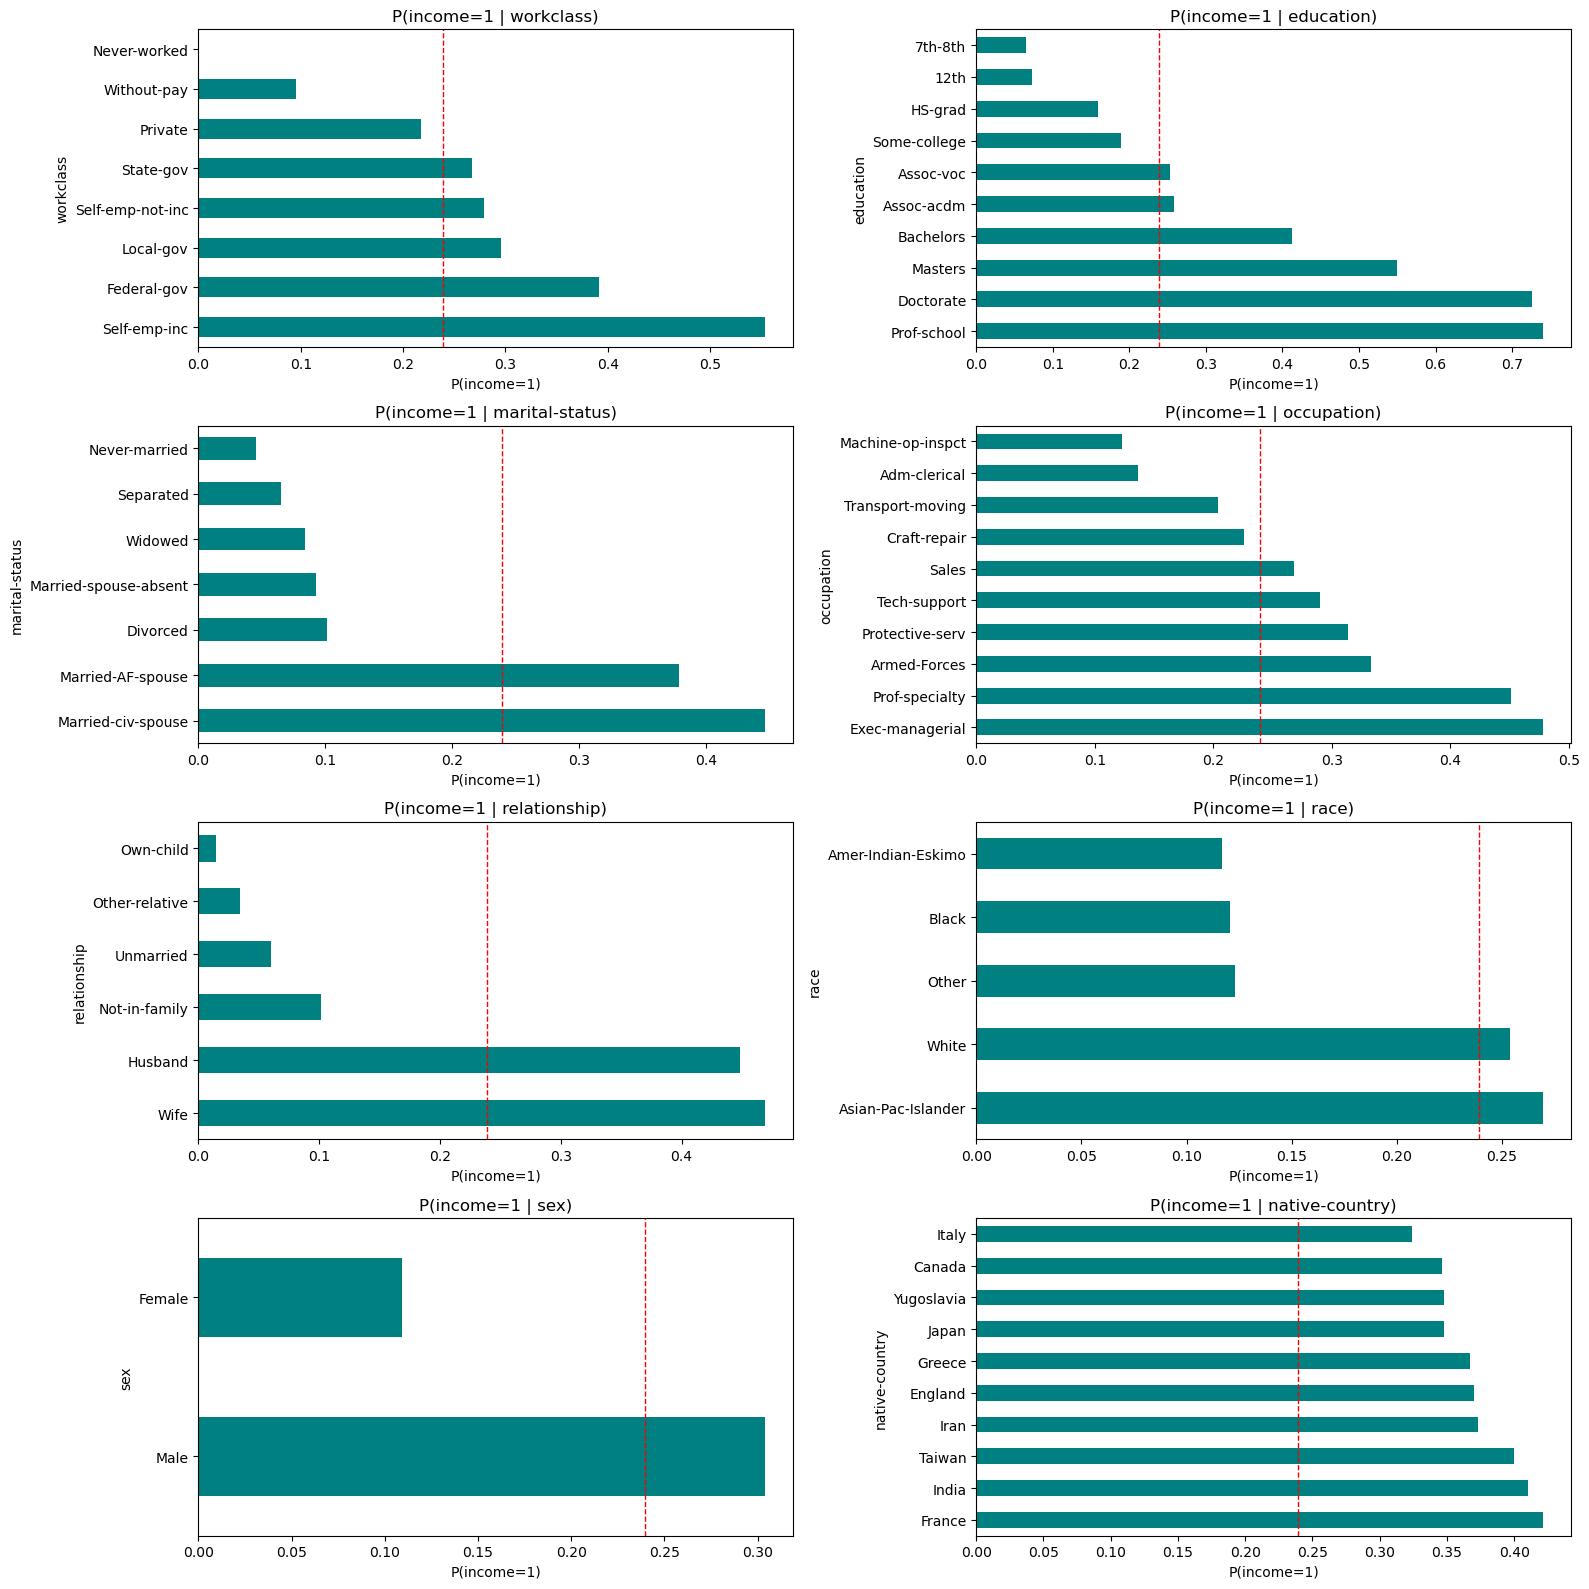

In [7]:
ncols = 2
nrows = int(np.ceil(len(cat_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).ravel()

for i, c in enumerate(cat_cols):
    vc = (
        df.groupby(c, observed=True)[target_col]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    vc.plot(kind="barh", ax=axes[i], color="teal")
    axes[i].axvline(df[target_col].mean(), color="red", ls="--", lw=1)
    axes[i].set_title(f"P({target_col}=1 | {c})")
    axes[i].set_xlabel("P(income=1)")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [8]:
numeric_transformer = Pipeline([
('imputer', SimpleImputer(strategy="median")),
])
categorical_transformer = Pipeline([
("imputer", SimpleImputer(strategy='most_frequent')), 
("encoder", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])
preproc = ColumnTransformer ([
('num', numeric_transformer, num_cols),
('cat', categorical_transformer, cat_cols),
], remainder='drop')

feature_names = num_cols + cat_cols
X= df.drop(columns=target_col)
y = df[target_col].astype(int)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, stratify=y, random_state=RNG)
print(f"Trening: {X_train.shape} Test: {X_test.shape}") 
print(f"Rozkład klas (trening): {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}")

Trening: (36631, 14) Test: (12211, 14)
Rozkład klas (trening): {0: 0.761, 1: 0.239}


In [9]:
#Dopasowanie preprocessingu tylko na zbiorze treningowym
X_train_prep = preproc.fit_transform(X_train)
X_test_prep = preproc.transform(X_test)

#Dla bezpieczenstwa, gdyby wynik był macierzą sparse
if hasattr(X_train_prep, "toarray"):
    X_train_prep = X_train_prep.toarray()
    X_test_prep = X_test_prep.toarray()

feature_names = num_cols + cat_cols

full_tree = DecisionTreeClassifier(random_state=RNG)
full_tree.fit(X_train_prep, y_train)

y_train_pred = full_tree.predict(X_train_prep)
y_test_pred = full_tree.predict(X_test_prep)

print("Pełne drzewo")
print("Train accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Test accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("Głębokość drzewa:", full_tree.get_depth())
print("Liczba liści:", full_tree.get_n_leaves())
print("Overfit gap:", round(accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred), 4))

Pełne drzewo
Train accuracy: 0.9999
Test accuracy: 0.8178
Głębokość drzewa: 44
Liczba liści: 5450
Overfit gap: 0.1822


Pełne drzewo osiąga bardzo wysoką dokładność na zbiorze treningowym, ale niższą na testowym. Różnica między train accuracy i test accuracy wskazuje na przeuczenie modelu.

Najlepsza głębokość: 7
Najlepszy wynik CV: 0.854


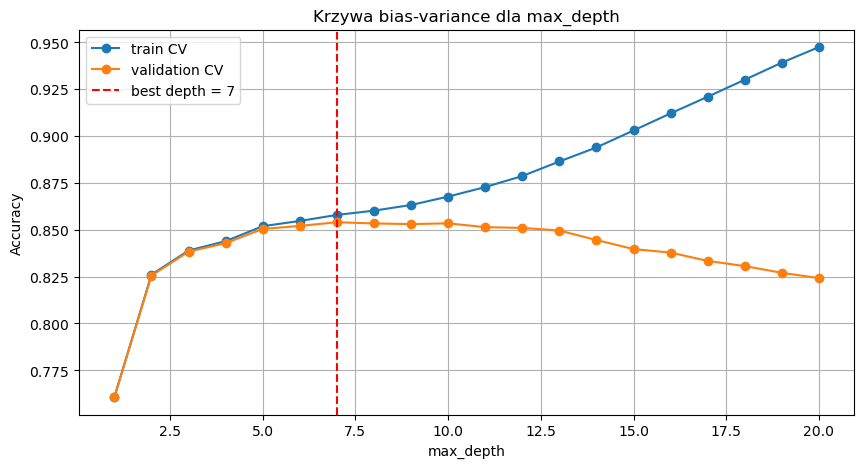

In [10]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG)

tree_pipe = Pipeline([
    ("preproc", preproc),
    ("tree", DecisionTreeClassifier(random_state=RNG))
])

param_grid_depth = {
    "tree__max_depth": list(range(1, 21))
}

gs_depth = GridSearchCV(
    tree_pipe,
    param_grid=param_grid_depth,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1
)

gs_depth.fit(X_train, y_train)

depth_results = pd.DataFrame(gs_depth.cv_results_)
depth_results["max_depth"] = depth_results["param_tree__max_depth"].astype(int)

best_d = gs_depth.best_params_["tree__max_depth"]

print("Najlepsza głębokość:", best_d)
print("Najlepszy wynik CV:", round(gs_depth.best_score_, 4))

plt.figure(figsize=(10, 5))
plt.plot(depth_results["max_depth"], depth_results["mean_train_score"], marker="o", label="train CV")
plt.plot(depth_results["max_depth"], depth_results["mean_test_score"], marker="o", label="validation CV")
plt.axvline(best_d, color="red", linestyle="--", label=f"best depth = {best_d}")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Krzywa bias-variance dla max_depth")
plt.legend()
plt.grid(True)
plt.show()

Najlepsza głębokość drzewa wyniosła `max_depth = 7`, a średnia dokładność walidacyjna to około `0.854`.

Na wykresie widać, że dla małych głębokości model jest zbyt prosty, dlatego wyniki treningowe i walidacyjne są niższe. Do głębokości około 7 wynik walidacyjny rośnie, co oznacza poprawę dopasowania modelu. Po przekroczeniu tej wartości dokładność treningowa dalej rośnie, ale dokładność walidacyjna zaczyna spadać. Oznacza to przeuczanie drzewa, czyli wzrost wariancji modelu.

In [11]:
path = full_tree.cost_complexity_pruning_path(X_train_prep, y_train)
alphas = np.unique(path.ccp_alphas)

print("Liczba wartości alpha:", len(alphas))
print("Pierwsze alpha:", alphas[:5])
print("Ostatnie alpha:", alphas[-5:])

Liczba wartości alpha: 1149
Pierwsze alpha: [0.00000000e+00 9.09976068e-06 1.31246548e-05 1.32230897e-05
 1.32360155e-05]
Ostatnie alpha: [0.01190093 0.01233601 0.02006751 0.02509139 0.05987019]


In [12]:
#tylko czesc wartości alpha, żeby obliczenia były szybsze
n_alphas = 80

if len(alphas) > n_alphas:
    idx = np.linspace(0, len(alphas) - 1, n_alphas, dtype=int)
    alphas_sample = alphas[idx]
else:
    alphas_sample = alphas

print("Liczba wszystkich alpha:", len(alphas))
print("Liczba użytych alpha:", len(alphas_sample))

Liczba wszystkich alpha: 1149
Liczba użytych alpha: 80


In [13]:
ccp_rows = []

for alpha in alphas_sample:
    tree = DecisionTreeClassifier(random_state=RNG, ccp_alpha=alpha)
    tree.fit(X_train_prep, y_train)
    
    train_pred = tree.predict(X_train_prep)
    test_pred = tree.predict(X_test_prep)
    
    ccp_rows.append({
        "ccp_alpha": alpha,
        "depth": tree.get_depth(),
        "leaves": tree.get_n_leaves(),
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
    })

ccp_df = pd.DataFrame(ccp_rows)
display(ccp_df.head())
display(ccp_df.tail())

,ccp_alpha,depth,leaves,train_accuracy,test_accuracy
0,0.000000,44,5450,0.999945,0.817787
1,0.000015,44,5391,0.999536,0.818524
2,0.000017,44,5293,0.998635,0.819179
3,0.000018,44,5207,0.997843,0.820080
4,0.000018,44,5147,0.997297,0.820899


,ccp_alpha,depth,leaves,train_accuracy,test_accuracy
75,0.000143,16,72,0.864514,0.859880
76,0.000189,16,53,0.862057,0.859062
77,0.000304,9,32,0.855287,0.853657
78,0.001572,7,16,0.852666,0.855213
79,0.059870,0,1,0.760722,0.760708


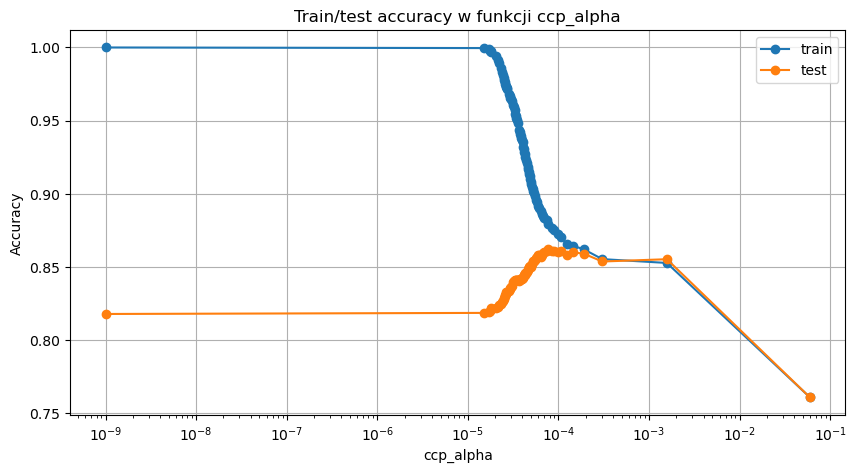

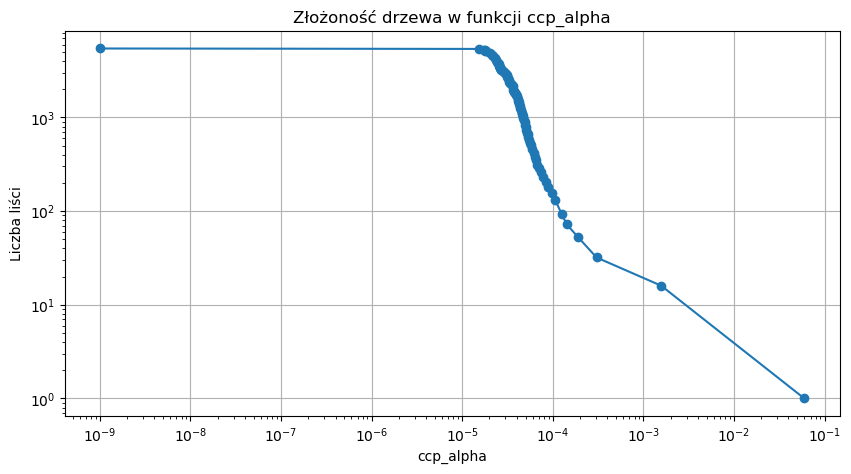

In [14]:
alpha_plot = np.maximum(ccp_df["ccp_alpha"], 1e-9)

plt.figure(figsize=(10, 5))
plt.plot(alpha_plot, ccp_df["train_accuracy"], marker="o", label="train")
plt.plot(alpha_plot, ccp_df["test_accuracy"], marker="o", label="test")
plt.xscale("log")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Train/test accuracy w funkcji ccp_alpha")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(alpha_plot, ccp_df["leaves"], marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("ccp_alpha")
plt.ylabel("Liczba liści")
plt.title("Złożoność drzewa w funkcji ccp_alpha")
plt.grid(True)
plt.show()

Wraz ze wzrostem `ccp_alpha` drzewo jest coraz silniej przycinane: spada liczba liści oraz dokładność na zbiorze treningowym. Dla bardzo małych wartości `alpha` drzewo jest pełne i mocno przeuczone - train accuracy jest bliskie 1, a test accuracy wyraźnie niższe. Najlepszy wynik testowy pojawia się dla pośrednich wartości `ccp_alpha`, gdzie model jest prostszy i lepiej generalizuje. Przy zbyt dużym `alpha` drzewo zostaje nadmiernie uproszczone, co obniża skuteczność.

In [15]:
ccp_pipe = Pipeline([
    ("preproc", preproc),
    ("tree", DecisionTreeClassifier(random_state=RNG))
])

param_grid_ccp = {
    "tree__ccp_alpha": alphas_sample
}

gs_ccp = GridSearchCV(
    ccp_pipe,
    param_grid=param_grid_ccp,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

gs_ccp.fit(X_train, y_train)

best_alpha = gs_ccp.best_params_["tree__ccp_alpha"]

print("Najlepsze ccp_alpha:", best_alpha)
print("Najlepszy wynik CV:", round(gs_ccp.best_score_, 4))

Najlepsze ccp_alpha: 0.0001429259618110296
Najlepszy wynik CV: 0.8582


In [16]:
def evaluate_tree_model(name, model):
    model.fit(X_train_prep, y_train)
    
    train_pred = model.predict(X_train_prep)
    test_pred = model.predict(X_test_prep)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    return {
        "model": name,
        "depth": model.get_depth(),
        "leaves": model.get_n_leaves(),
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "f1": f1_score(y_test, test_pred, zero_division=0),
        "overfit_gap": train_acc - test_acc
    }


models_to_compare = [
    (
        "Pełne drzewo",
        DecisionTreeClassifier(random_state=RNG)
    ),
    (
        f"Pre-pruning max_depth={best_d}",
        DecisionTreeClassifier(max_depth=best_d, random_state=RNG)
    ),
    (
        "Pre-pruning kombinowane",
        DecisionTreeClassifier(
            max_depth=10,
            min_samples_leaf=20,
            min_impurity_decrease=1e-4,
            random_state=RNG
        )
    ),
    (
        f"Post-pruning CCP alpha={best_alpha:.6f}",
        DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=RNG)
    )
]

comparison_df = pd.DataFrame([
    evaluate_tree_model(name, model)
    for name, model in models_to_compare
])

comparison_df = comparison_df.sort_values("test_accuracy", ascending=False)
display(comparison_df)

,model,depth,leaves,train_accuracy,test_accuracy,f1,overfit_gap
3,Post-pruning CCP alpha=0.000143,16,72,0.864514,0.859880,0.680486,0.004633
1,Pre-pruning max_depth=7,7,87,0.858481,0.858734,0.652568,-0.000253
2,Pre-pruning kombinowane,10,68,0.858945,0.855622,0.674903,0.003323
0,Pełne drzewo,44,5450,0.999945,0.817787,0.624979,0.182158


Najlepszy wynik testowy uzyskało drzewo po post-pruningu CCP i jednocześnie ma ono niewielki overfit gap. Model z `max_depth = 7` również działa bardzo dobrze, ale ma minimalnie niższy wynik testowy i F1. Pełne drzewo jest wyraźnie przeuczone: osiąga prawie idealny wynik na zbiorze treningowym, ale dużo słabszy na testowym, a luka overfittingu jest największa.

Do produkcji wybrałabym model po CCP. Ma więcej poziomów niż model `max_depth = 7`, ale nadal jest znacznie prostszy od pełnego drzewa i lepiej generalizuje.

In [17]:
viz_tree = DecisionTreeClassifier(max_depth=3, random_state=RNG)
viz_tree.fit(X_train_prep, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [20]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

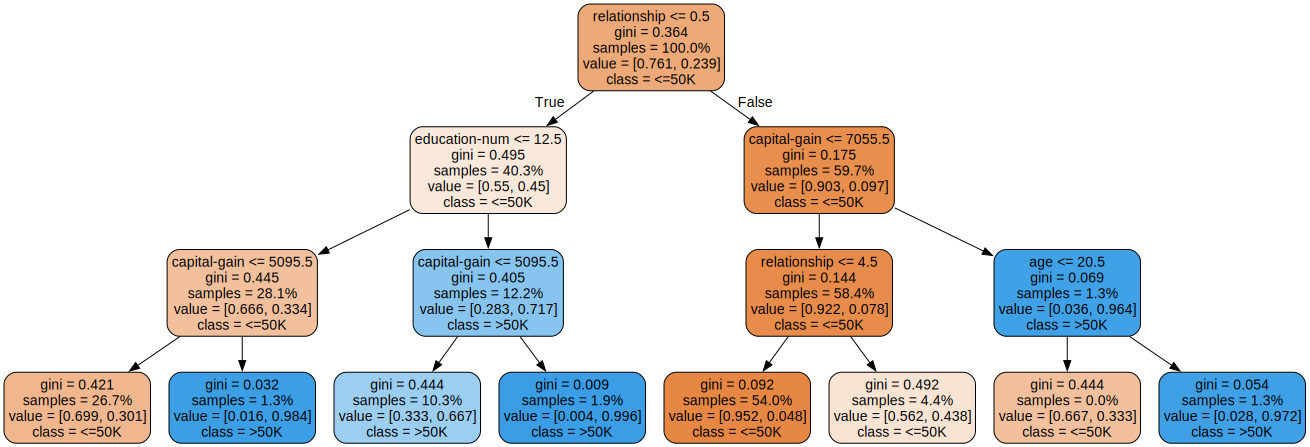

In [22]:
import graphviz
    
dot_data = export_graphviz(
    viz_tree,
    out_file=None,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    proportion=True,
    impurity=True
)
    
display(graphviz.Source(dot_data))

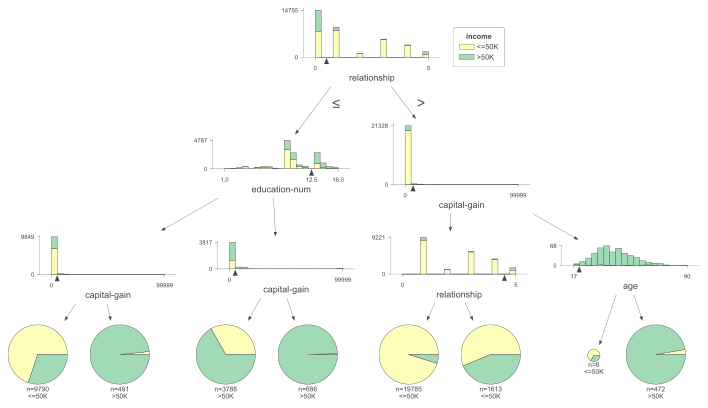

In [23]:
from dtreeviz import model as dtreeviz_model
    
X_train_viz = pd.DataFrame(X_train_prep, columns=feature_names)
    
viz = dtreeviz_model(
    viz_tree,
    X_train=X_train_viz,
    y_train=y_train.to_numpy(),
    feature_names=feature_names,
    target_name="income",
    class_names=["<=50K", ">50K"]
)
    
display(viz.view())

Wizualizacje pokazują ograniczone drzewo decyzyjne o głębokości 3. Najważniejszym pierwszym podziałem jest cecha `relationship`, a następnie model wykorzystuje głównie `education-num`, `capital-gain` oraz `age`. Oznacza to, że decyzja modelu silnie zależy od relacji rodzinnej, poziomu edukacji, zysków kapitałowych i wieku.

Wizualizacja Graphviz jest bardziej techniczna i czytelnie pokazuje warunki podziału, wartości `gini`, udział próbek oraz przewidywaną klasę w każdym węźle. dtreeviz jest bardziej interpretowalny wizualnie, ponieważ dodatkowo pokazuje rozkłady wartości cech i proporcje klas w liściach.

In [24]:
from sklearn.inspection import permutation_importance

ccp_tree = DecisionTreeClassifier(random_state=RNG, ccp_alpha=best_alpha)
ccp_tree.fit(X_train_prep, y_train)

y_pred_ccp = ccp_tree.predict(X_test_prep)

print("CCP tree depth:", ccp_tree.get_depth())
print("CCP tree leaves:", ccp_tree.get_n_leaves())
print("Test accuracy:", accuracy_score(y_test, y_pred_ccp))

CCP tree depth: 16
CCP tree leaves: 72
Test accuracy: 0.8598804356727541


,feature,importance
10,relationship,0.416650
3,capital-gain,0.211677
2,education-num,0.209686
4,capital-loss,0.071025
0,age,0.037191
5,hours-per-week,0.033170
6,workclass,0.008988
9,occupation,0.006703
1,fnlwgt,0.002165
13,native-country,0.001919


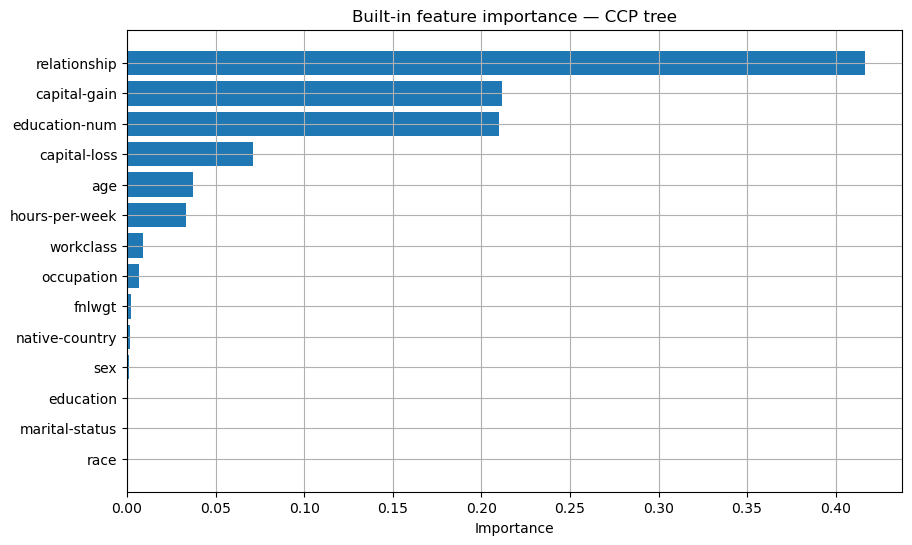

In [25]:
builtin_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": ccp_tree.feature_importances_
}).sort_values("importance", ascending=False)

display(builtin_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    builtin_importance.head(15)["feature"][::-1],
    builtin_importance.head(15)["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Built-in feature importance - CCP tree")
plt.grid(True)
plt.show()

,feature,importance_mean,importance_std
10,relationship,0.060920,0.002013
3,capital-gain,0.047564,0.001230
2,education-num,0.047392,0.001769
0,age,0.016125,0.002103
4,capital-loss,0.010728,0.000898
5,hours-per-week,0.008451,0.001178
6,workclass,0.002571,0.000809
9,occupation,0.002137,0.000732
1,fnlwgt,0.001703,0.000823
13,native-country,0.000491,0.000384


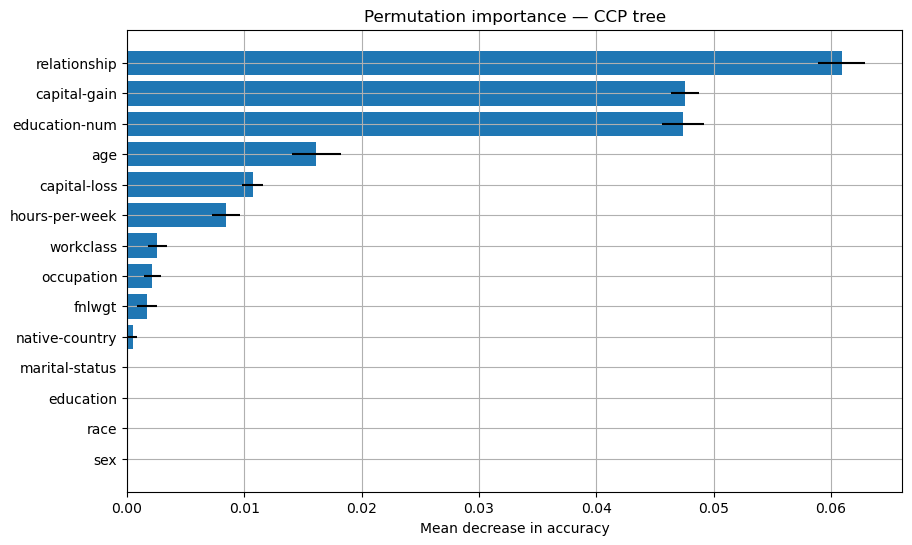

In [26]:
perm = permutation_importance(
    ccp_tree,
    X_test_prep,
    y_test,
    n_repeats=10,
    random_state=RNG,
    scoring="accuracy",
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    perm_importance.head(15)["feature"][::-1],
    perm_importance.head(15)["importance_mean"][::-1],
    xerr=perm_importance.head(15)["importance_std"][::-1]
)
plt.xlabel("Mean decrease in accuracy")
plt.title("Permutation importance - CCP tree")
plt.grid(True)
plt.show()

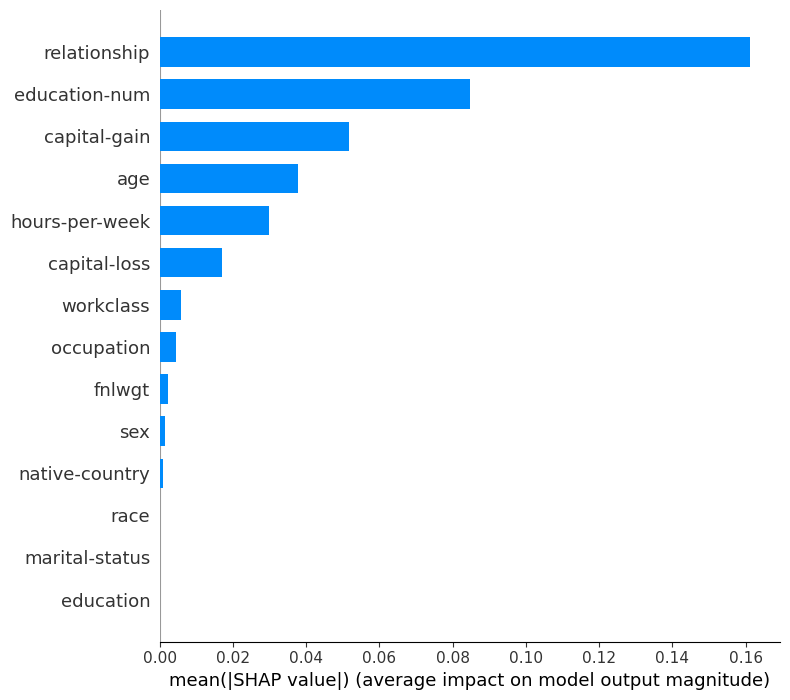

In [29]:
# bierzemy maksymalnie 1000 losowych rekordów ze zbioru testowego
sample_size = min(1000, X_test_prep.shape[0])

rng = np.random.default_rng(RNG)
sample_idx = rng.choice(X_test_prep.shape[0], size=sample_size, replace=False)

X_shap = X_test_prep[sample_idx]
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

explainer = shap.TreeExplainer(ccp_tree)
shap_values = explainer.shap_values(X_shap)

# dla klasy pozytywnej income = 1
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

shap.summary_plot(
    shap_values_class1,
    X_shap_df,
    plot_type="bar",
    max_display=15
)

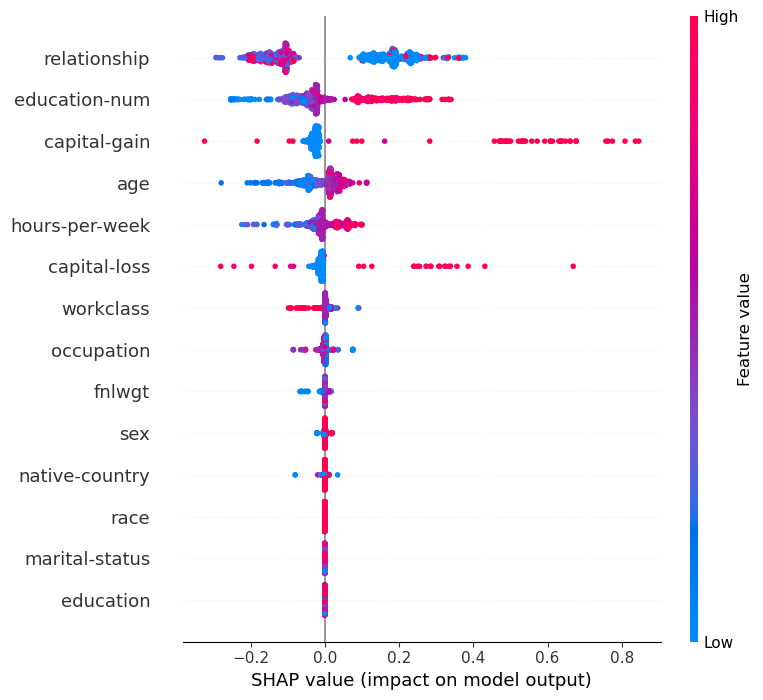

In [30]:
shap.summary_plot(
    shap_values_class1,
    X_shap_df,
    max_display=15
)

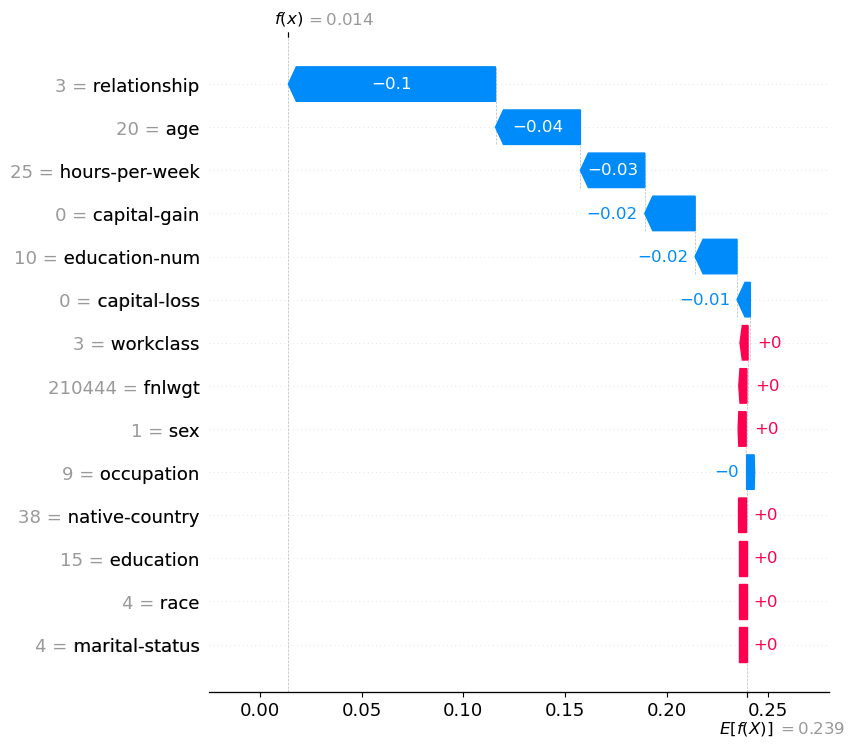

In [31]:
i = 0

if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

shap_explanation = shap.Explanation(
    values=shap_values_class1[i],
    base_values=base_value,
    data=X_shap_df.iloc[i],
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation, max_display=15)

Rankingi ważności cech są w dużej mierze spójne. We wszystkich trzech metodach jako najważniejsze pojawiają się przede wszystkim `relationship`, `capital-gain`, `education-num`, a następnie `age`, `hours-per-week` i `capital-loss`. Oznacza to, że model CCP podejmuje decyzje głównie na podstawie relacji rodzinnej, zysków kapitałowych, poziomu edukacji oraz wieku.

Największą ważność według built-in importance ma `relationship`. Permutation importance oraz SHAP również wskazuje `relationship` jako najważniejszą cechę.

Różnice między rankingami są naturalne, ponieważ każda metoda mierzy ważność inaczej. Built-in importance bazuje na redukcji nieczystości w drzewie, permutation importance sprawdza wpływ cechy na wynik testowy po jej zaburzeniu, a SHAP pokazuje wkład cech w konkretne predykcje. Rozbieżności mogą wynikać także z korelacji między cechami oraz z kodowania zmiennych kategorycznych przez `OrdinalEncoder`.

Wykres waterfall pokazuje pojedynczą predykcję, dla której cechy takie jak `relationship`, `age`, `hours-per-week`, `capital-gain` i `education-num` obniżają prawdopodobieństwo klasy `>50K`. Końcowa wartość predykcji jest niska, więc model klasyfikuje tę obserwację jako `<=50K`.

In [33]:
fairness_df = X_test.copy()
fairness_df["y_true"] = y_test.values
fairness_df["y_pred"] = y_pred_ccp

fairness_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,y_true,y_pred
44696,38,Private,159179,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,0,0
31814,21,Without-pay,232719,HS-grad,9,Never-married,Craft-repair,Own-child,Black,Male,0,0,40,United-States,0,0
19694,34,Private,340940,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,7298,0,60,United-States,1,1
33136,21,Private,190968,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States,0,0
34810,30,Self-emp-not-inc,31510,Assoc-acdm,12,Divorced,Craft-repair,Not-in-family,White,Male,0,0,50,United-States,0,0


In [34]:
def fairness_by_group(data, group_col):
    rows = []

    for group_value, group_data in data.groupby(group_col, observed=True):
        y_true_g = group_data["y_true"]
        y_pred_g = group_data["y_pred"]

        tn, fp, fn, tp = confusion_matrix(
            y_true_g,
            y_pred_g,
            labels=[0, 1]
        ).ravel()

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        positive_rate = y_pred_g.mean()  # demographic parity
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

        rows.append({
            group_col: group_value,
            "n": len(group_data),
            "accuracy": accuracy,
            "positive_prediction_rate": positive_rate,
            "TPR": tpr,
            "FPR": fpr
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)

In [35]:
fairness_sex = fairness_by_group(fairness_df, "sex")
display(fairness_sex)

,sex,n,accuracy,positive_prediction_rate,TPR,FPR
1,Male,8187,0.828753,0.246122,0.624139,0.082896
0,Female,4024,0.923211,0.103877,0.620309,0.038365


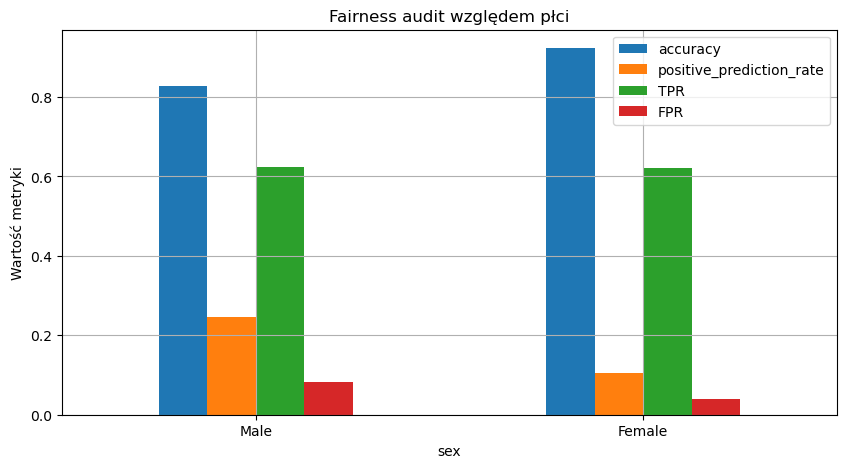

In [36]:
fairness_sex.set_index("sex")[["accuracy", "positive_prediction_rate", "TPR", "FPR"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Fairness audit względem płci")
plt.ylabel("Wartość metryki")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

In [37]:
fairness_race = fairness_by_group(fairness_df, "race")
display(fairness_race)

,race,n,accuracy,positive_prediction_rate,TPR,FPR
4,White,10385,0.853924,0.210496,0.626753,0.068681
2,Black,1208,0.919702,0.108444,0.611842,0.035985
1,Asian-Pac-Islander,393,0.809160,0.241730,0.598039,0.116838
0,Amer-Indian-Eskimo,118,0.889831,0.093220,0.444444,0.030000
3,Other,107,0.915888,0.093458,0.545455,0.041667


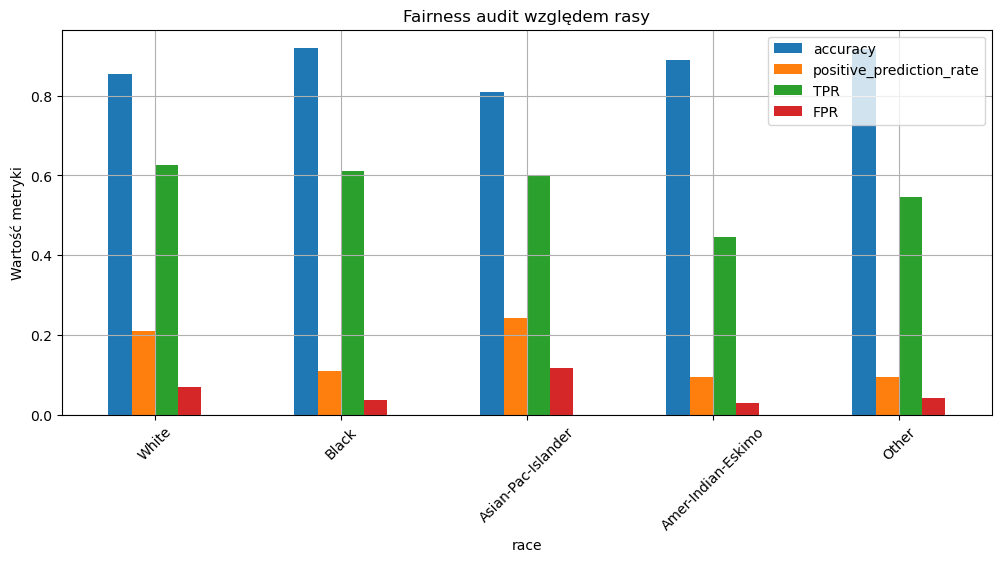

In [38]:
fairness_race.set_index("race")[["accuracy", "positive_prediction_rate", "TPR", "FPR"]].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Fairness audit względem rasy")
plt.ylabel("Wartość metryki")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Fairness audit pokazuje widoczne różnice między podgrupami. Dla płci dokładność jest wyższa dla kobiet, ale model znacznie częściej przewiduje klasę pozytywną dla mężczyzn. Oznacza to naruszenie demographic parity. Jednocześnie TPR jest bardzo podobny dla obu grup, około `0.62`, więc pod względem wykrywania rzeczywistych przypadków model działa podobnie. FPR jest jednak wyższy dla mężczyzn, co oznacza częstsze fałszywe predykcje pozytywne w tej grupie.

Dla rasy również widać różnice. Najwyższy positive prediction rate występuje dla grup `Asian-Pac-Islander` i `White`, a znacznie niższy dla `Black`, `Amer-Indian-Eskimo` oraz `Other`. Różnice występują także w TPR i FPR. Szczególnie należy uważać przy interpretacji mniejszych grup, takich jak `Amer-Indian-Eskimo` i `Other`, ponieważ mają mało obserwacji, więc metryki mogą być mniej stabilne.

Wyniki wskazują na potencjalne ryzyko fairness w modelu trenowanym na zbiorze Adult. Model odzwierciedla zależności obecne w danych historycznych, które mogą zawierać nierówności społeczne związane z płcią i rasą.

In [41]:
n_estimators_list = [10, 20, 50, 100, 200, 300, 500]

rf = RandomForestClassifier(
    n_estimators=10,
    warm_start=True,
    oob_score=True,
    bootstrap=True,
    random_state=RNG,
    n_jobs=-1
)

rf_convergence_rows = []

for n in n_estimators_list:
    rf.set_params(n_estimators=n)
    rf.fit(X_train_prep, y_train)
    
    y_test_pred = rf.predict(X_test_prep)
    
    rf_convergence_rows.append({
        "n_estimators": n,
        "oob_score": rf.oob_score_,
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred)
    })

rf_convergence_df = pd.DataFrame(rf_convergence_rows)
display(rf_convergence_df)

C:\Users\wesol\anaconda3\envs\DataScience\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
C:\Users\wesol\anaconda3\envs\DataScience\Lib\site-packages\sklearn\ensemble\_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.


,n_estimators,oob_score,test_accuracy,test_balanced_accuracy
0,10,0.833092,0.852346,0.758802
1,20,0.841337,0.854066,0.767204
2,50,0.849281,0.857178,0.773120
3,100,0.852311,0.858079,0.775472
4,200,0.853430,0.860044,0.779344
5,300,0.854577,0.859307,0.778273
6,500,0.854713,0.858980,0.777354


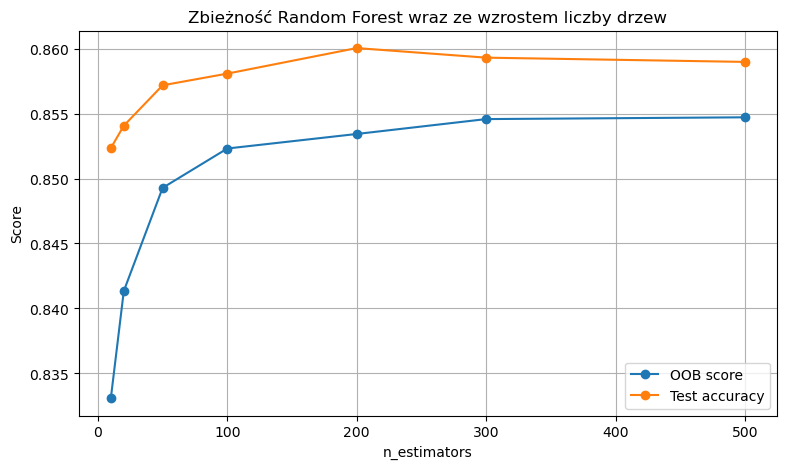

In [42]:
plt.figure(figsize=(9, 5))
plt.plot(rf_convergence_df["n_estimators"], rf_convergence_df["oob_score"], marker="o", label="OOB score")
plt.plot(rf_convergence_df["n_estimators"], rf_convergence_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Score")
plt.title("Zbieżność Random Forest wraz ze wzrostem liczby drzew")
plt.legend()
plt.grid(True)
plt.show()

Wraz ze wzrostem liczby drzew jakość Random Forest stabilizuje się. Dla małej liczby estymatorów wynik OOB jest mniej wiarygodny, co potwierdzają ostrzeżenia - część obserwacji nie ma jeszcze wystarczającej liczby predykcji out-of-bag. 

Od około 100–200 drzew wyniki OOB i test accuracy zmieniają się już niewiele. Najwyższy wynik testowy pojawia się przy około 200 drzewach, a dalsze zwiększanie liczby drzew nie daje istotnej poprawy.

In [43]:
max_features_list = [1, 2, 4, "sqrt", "log2", 0.5, None]

max_features_rows = []

for mf in max_features_list:
    rf_mf = RandomForestClassifier(
        n_estimators=200,
        max_features=mf,
        oob_score=True,
        bootstrap=True,
        random_state=RNG,
        n_jobs=-1
    )
    
    rf_mf.fit(X_train_prep, y_train)
    y_test_pred = rf_mf.predict(X_test_prep)
    
    max_features_rows.append({
        "max_features": str(mf),
        "oob_score": rf_mf.oob_score_,
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "test_f1": f1_score(y_test, y_test_pred)
    })

max_features_df = pd.DataFrame(max_features_rows)
display(max_features_df.sort_values("test_accuracy", ascending=False))

,max_features,oob_score,test_accuracy,test_balanced_accuracy,test_f1
1,2,0.854276,0.860044,0.778054,0.679783
4,log2,0.853430,0.860044,0.779344,0.681097
3,sqrt,0.853430,0.860044,0.779344,0.681097
2,4,0.854195,0.859799,0.778479,0.680000
5,0.5,0.853785,0.859062,0.778112,0.678978
0,1,0.852584,0.857506,0.772163,0.671450
6,None,0.851219,0.856850,0.777479,0.676416


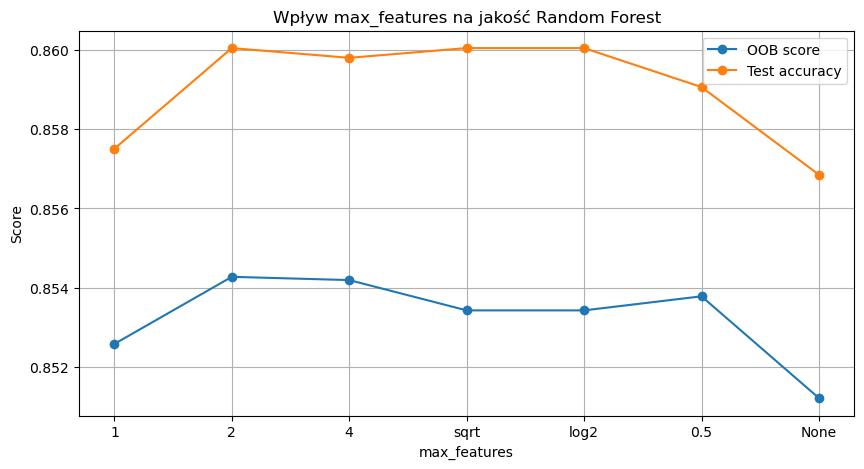

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(max_features_df["max_features"], max_features_df["oob_score"], marker="o", label="OOB score")
plt.plot(max_features_df["max_features"], max_features_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("max_features")
plt.ylabel("Score")
plt.title("Wpływ max_features na jakość Random Forest")
plt.legend()
plt.grid(True)
plt.show()

Najlepsze wyniki testowe uzyskały ustawienia `max_features = 2`, `sqrt` oraz `log2`. Najwyższy wynik OOB pojawił się dla `max_features = 2`, więc można uznać tę wartość za najlepszy kompromis.

Zbyt małe `max_features`, np. 1, ogranicza model, ponieważ przy każdym podziale drzewo widzi bardzo mało cech i może wybierać słabsze podziały. Z kolei `max_features = None` daje najgorszy wynik, ponieważ każde drzewo może korzystać ze wszystkich cech, przez co drzewa stają się bardziej podobne do siebie.

In [46]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, 0.8]),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
    }
    
    rf = RandomForestClassifier(
        **params,
        random_state=RNG,
        n_jobs=-1
    )
    
    scores = cross_val_score(
        rf,
        X_train_prep,
        y_train,
        cv=5,
        scoring="balanced_accuracy",
        n_jobs=-1
    )
    
    return scores.mean()


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RNG)
)

study.optimize(objective, n_trials=25)

print("Najlepszy wynik balanced accuracy:", study.best_value)
print("Najlepsze parametry:")
print(study.best_params)

[I 2026-04-29 14:10:36,373] A new study created in memory with name: no-name-eb16780f-3b18-4106-9c25-56fb5c1aad45
[I 2026-04-29 14:10:56,309] Trial 0 finished with value: 0.7650817372703778 and parameters: {'n_estimators': 200, 'max_depth': 29, 'max_features': 'sqrt', 'min_samples_leaf': 18, 'min_samples_split': 19}. Best is trial 0 with value: 0.7650817372703778.
[I 2026-04-29 14:11:10,503] Trial 1 finished with value: 0.6621564180216218 and parameters: {'n_estimators': 400, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 17}. Best is trial 0 with value: 0.7650817372703778.
[I 2026-04-29 14:11:22,421] Trial 2 finished with value: 0.7553359982661063 and parameters: {'n_estimators': 250, 'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'min_samples_split': 7}. Best is trial 0 with value: 0.7650817372703778.
[I 2026-04-29 14:12:03,716] Trial 3 finished with value: 0.772043725582306 and parameters: {'n_estimators': 300, 'max_depth': 19, 

Najlepszy wynik balanced accuracy: 0.77773216810658
Najlepsze parametry:
{'n_estimators': 100, 'max_depth': 30, 'max_features': 0.3, 'min_samples_leaf': 3, 'min_samples_split': 20}


In [47]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=RNG,
    n_jobs=-1
)

best_rf.fit(X_train_prep, y_train)

y_train_pred_rf = best_rf.predict(X_train_prep)
y_test_pred_rf = best_rf.predict(X_test_prep)

print("Random Forest Optuna")
print("Train accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Test balanced accuracy:", balanced_accuracy_score(y_test, y_test_pred_rf))
print("Test F1:", f1_score(y_test, y_test_pred_rf))

Random Forest Optuna
Train accuracy: 0.9021320739264558
Test accuracy: 0.867005159282614
Test balanced accuracy: 0.7801659857040213
Test F1: 0.6882917466410748


In [48]:
dt_ccp = DecisionTreeClassifier(
    random_state=RNG,
    ccp_alpha=best_alpha
)

hgb = HistGradientBoostingClassifier(
    max_iter=300,
    random_state=RNG
)

models_7 = [
    ("Decision Tree CCP", dt_ccp),
    ("Random Forest Optuna", best_rf),
    ("HistGradientBoosting", hgb)
]

comparison_7_rows = []

for name, model in models_7:
    model.fit(X_train_prep, y_train)
    
    y_train_pred = model.predict(X_train_prep)
    y_test_pred = model.predict(X_test_prep)
    
    comparison_7_rows.append({
        "model": name,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "overfit_gap": accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred)
    })

comparison_7_df = pd.DataFrame(comparison_7_rows)
display(comparison_7_df.sort_values("test_accuracy", ascending=False))

,model,train_accuracy,test_accuracy,balanced_accuracy,f1,overfit_gap
2,HistGradientBoosting,0.885834,0.876669,0.800358,0.717342,0.009166
1,Random Forest Optuna,0.902132,0.867005,0.780166,0.688292,0.035127
0,Decision Tree CCP,0.864514,0.859880,0.778884,0.680486,0.004633


Najlepszy wynik uzyskał `HistGradientBoosting`: ma najwyższe test_accuracy, najwyższe balanced_accuracy oraz najwyższe F1. Oznacza to, że najlepiej radzi sobie zarówno ogólnie, jak i z mniej liczną klasą.

Random Forest poprawia wynik względem pojedynczego drzewa CCP, szczególnie dla `balanced_accuracy` i `F1`, ale ma też większy `overfit_gap`, czyli mocniej dopasowuje się do zbioru treningowego. Decision Tree CCP jest najprostszy i najbardziej interpretowalny, ale osiąga najniższy wynik.

Do produkcji pod względem jakości predykcji wybrałabym `HistGradientBoosting`. Ceną za poprawę jakości jest mniejsza interpretowalność, większa złożoność modelu oraz trudniejsze wyjaśnianie pojedynczych predykcji w porównaniu z pojedynczym drzewem decyzyjnym.

,feature,importance
3,capital-gain,0.179490
10,relationship,0.168379
2,education-num,0.128969
8,marital-status,0.106331
0,age,0.098484
1,fnlwgt,0.071106
5,hours-per-week,0.066089
4,capital-loss,0.049842
9,occupation,0.042077
7,education,0.037042


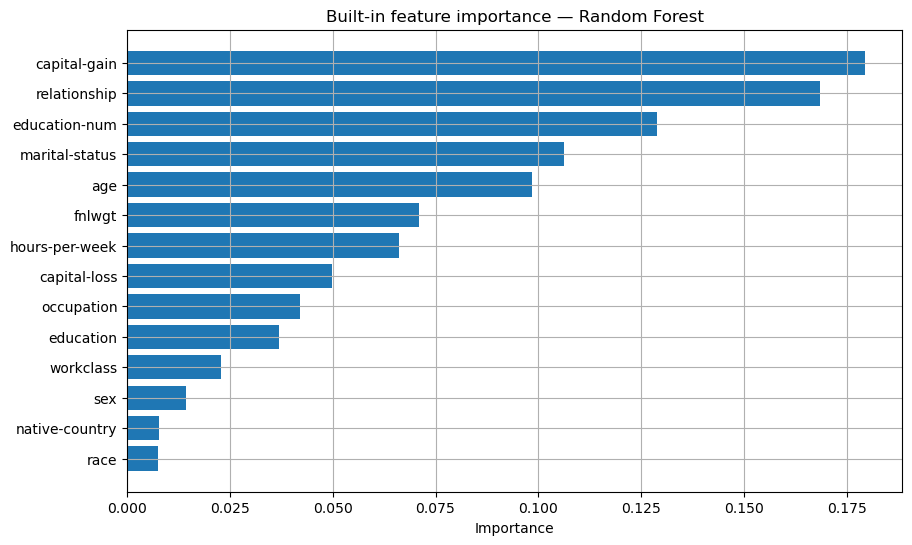

In [49]:
rf_builtin_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_builtin_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    rf_builtin_importance.head(15)["feature"][::-1],
    rf_builtin_importance.head(15)["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Built-in feature importance - Random Forest")
plt.grid(True)
plt.show()

,feature,importance_mean,importance_std
3,capital-gain,0.047310,0.001125
2,education-num,0.030473,0.001978
10,relationship,0.026869,0.001621
0,age,0.016526,0.001783
4,capital-loss,0.010400,0.000515
5,hours-per-week,0.009270,0.001646
8,marital-status,0.009131,0.001002
9,occupation,0.009008,0.001246
6,workclass,0.002997,0.000723
7,education,0.001376,0.001426


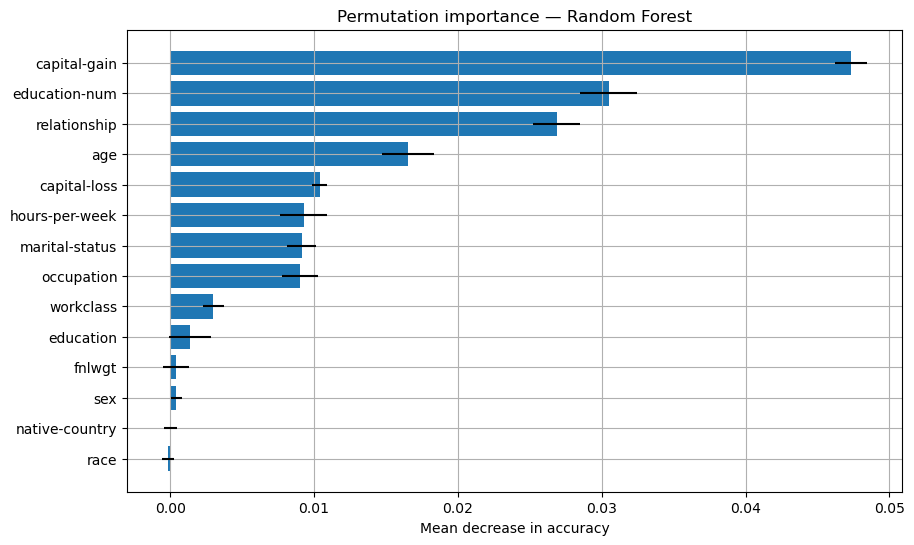

In [71]:
rf_perm = permutation_importance(
    best_rf,
    X_test_prep,
    y_test,
    n_repeats=10,
    random_state=RNG,
    scoring="accuracy",
    n_jobs=-1
)

rf_perm_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": rf_perm.importances_mean,
    "importance_std": rf_perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(rf_perm_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    rf_perm_importance.head(15)["feature"][::-1],
    rf_perm_importance.head(15)["importance_mean"][::-1],
    xerr=rf_perm_importance.head(15)["importance_std"][::-1]
)
plt.xlabel("Mean decrease in accuracy")
plt.title("Permutation importance - Random Forest")
plt.grid(True)
plt.show()

In [50]:
sample_size = min(1000, X_test_prep.shape[0])

rng = np.random.default_rng(RNG)
sample_idx = rng.choice(X_test_prep.shape[0], size=sample_size, replace=False)

X_shap_rf = X_test_prep[sample_idx]
X_shap_rf_df = pd.DataFrame(X_shap_rf, columns=feature_names)

rf_explainer = shap.TreeExplainer(best_rf)
rf_shap_values = rf_explainer.shap_values(X_shap_rf)

if isinstance(rf_shap_values, list):
    rf_shap_values_class1 = rf_shap_values[1]
else:
    rf_shap_values_class1 = rf_shap_values[:, :, 1] if rf_shap_values.ndim == 3 else rf_shap_values

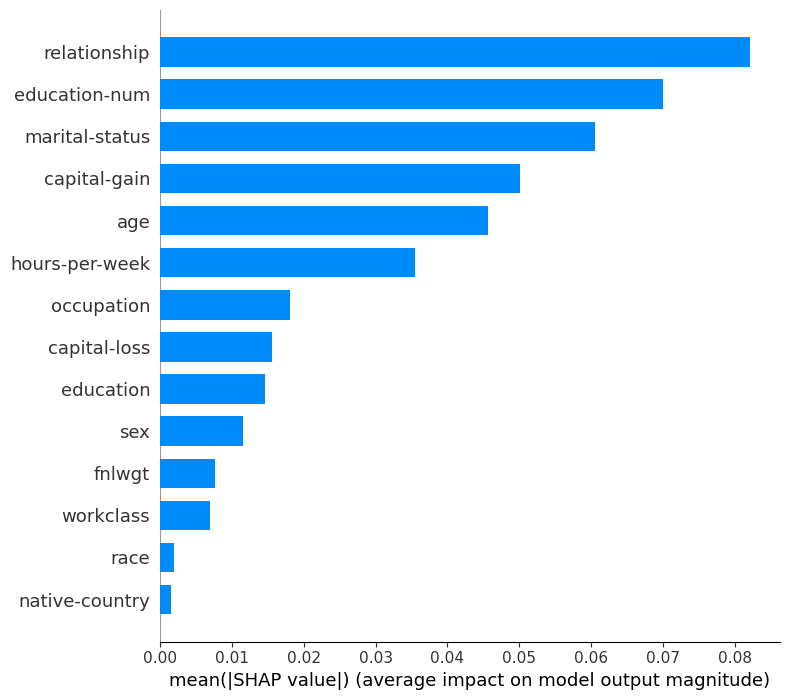

In [51]:
shap.summary_plot(
    rf_shap_values_class1,
    X_shap_rf_df,
    plot_type="bar",
    max_display=15
)

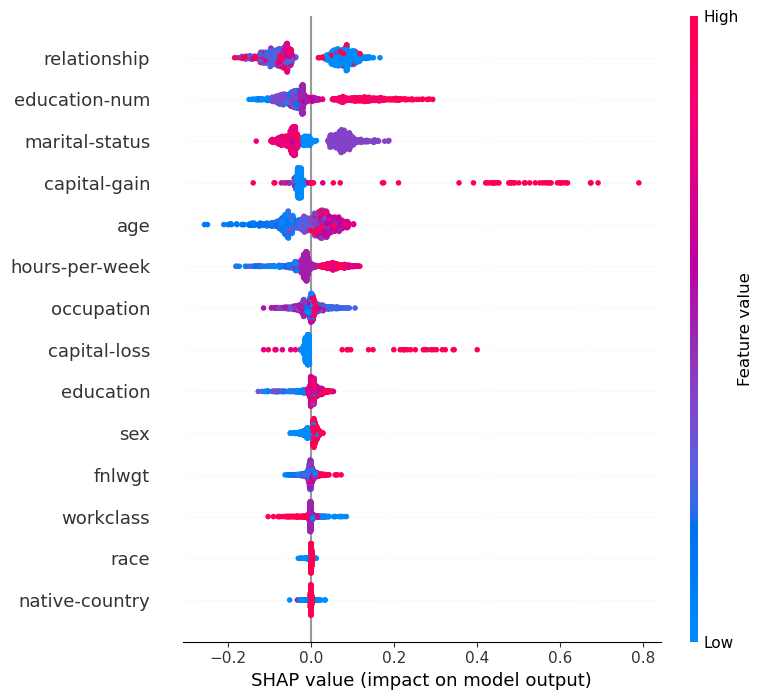

In [52]:
shap.summary_plot(
    rf_shap_values_class1,
    X_shap_rf_df,
    max_display=15
)

W Random Forest najważniejsze cechy są podobne jak w pojedynczym drzewie CCP, ale ranking jest bardziej rozłożony. Największe znaczenie mają `capital-gain`, `relationship`, `education-num`, `marital-status` oraz `age`. W porównaniu z pojedynczym drzewem większą rolę zaczynają odgrywać też cechy takie jak `marital-status`, `fnlwgt`, `education` i `sex`, ponieważ las losowy uśrednia wiele różnych drzew i może wykorzystywać cechy, które nie pojawiły się wysoko w jednym drzewie.

Ranking SHAP częściowo potwierdza built-in importance: bardzo ważne pozostają `relationship`, `education-num`, `marital-status`, `capital-gain` i `age`. Różnice w kolejności wynikają z tego, że built-in importance mierzy średni spadek nieczystości w drzewach, a SHAP pokazuje rzeczywisty wpływ cech na predykcje modelu.

Wykres SHAP pokazuje też kierunek wpływu cech. Wysokie wartości `capital-gain` oraz `education-num` zwykle zwiększają predykcję klasy `>50K`, natomiast niskie wartości tych cech obniżają prawdopodobieństwo tej klasy. Random Forest daje więc stabilniejszy i bardziej zróżnicowany ranking cech niż pojedyncze drzewo.

In [54]:
penguins = fetch_openml("penguins", version=1, as_frame=True, parser="auto")
penguins_df = penguins.frame.copy()

display(penguins_df.head())
print(penguins_df.shape)
print(penguins_df.isnull().sum())
print(penguins_df.dtypes)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


(344, 7)
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64
species              category
island               category
culmen_length_mm      float64
culmen_depth_mm       float64
flipper_length_mm     float64
body_mass_g           float64
sex                  category
dtype: object


In [55]:
#na
penguins_df = penguins_df.dropna().reset_index(drop=True)

#kolumna target
target_col = "species" if "species" in penguins_df.columns else penguins.target_names[0]

X_penguins = penguins_df.drop(columns=[target_col])
y_penguins_raw = penguins_df[target_col]

#kodowanie etykiety
label_encoder = LabelEncoder()
y_penguins = label_encoder.fit_transform(y_penguins_raw)

print("Klasy:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print("Rozmiar X:", X_penguins.shape)

Klasy: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}
Rozmiar X: (334, 6)


In [56]:
num_cols_penguins = X_penguins.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_penguins = X_penguins.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeryczne:", num_cols_penguins)
print("Kategoryczne:", cat_cols_penguins)

Numeryczne: ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
Kategoryczne: ['island', 'sex']


In [57]:
penguins_preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols_penguins),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_penguins)
])

X_penguins_prep = penguins_preproc.fit_transform(X_penguins)

print("Po preprocessingu:", X_penguins_prep.shape)

Po preprocessingu: (334, 10)


Po oczyszczeniu pozostały 334 rekordy. Zmienna docelowa `species` została zakodowana numerycznie, a cechy kategoryczne `island` i `sex` zakodowano metodą OneHotEncoder. Cechy numeryczne zostały przeskalowane za pomocą StandardScaler, co jest konieczne dla k-NN, ponieważ klasyfikator ten opiera się na odległościach między obserwacjami.

In [58]:
k_values = [1, 3, 5, 7, 9, 11, 15]
metrics = ["euclidean", "manhattan", "chebyshev"]
weights_list = ["uniform", "distance"]

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

knn_rows = []

for k in k_values:
    for metric in metrics:
        for weights in weights_list:
            knn = KNeighborsClassifier(
                n_neighbors=k,
                metric=metric,
                weights=weights
            )
            
            scores = cross_val_score(
                knn,
                X_penguins_prep,
                y_penguins,
                cv=cv5,
                scoring="accuracy"
            )
            
            knn_rows.append({
                "k": k,
                "metric": metric,
                "weights": weights,
                "cv_accuracy_mean": scores.mean(),
                "cv_accuracy_std": scores.std()
            })

knn_results = pd.DataFrame(knn_rows)
display(knn_results.sort_values("cv_accuracy_mean", ascending=False))

,k,metric,weights,cv_accuracy_mean,cv_accuracy_std
4,1,chebyshev,uniform,1.000000,0.000000
5,1,chebyshev,distance,1.000000,0.000000
38,15,manhattan,uniform,0.997015,0.005970
21,7,manhattan,distance,0.996970,0.006061
19,7,euclidean,distance,0.996970,0.006061
20,7,manhattan,uniform,0.996970,0.006061
23,7,chebyshev,distance,0.996970,0.006061
27,9,manhattan,distance,0.996970,0.006061
6,3,euclidean,uniform,0.993985,0.007368
7,3,euclidean,distance,0.993985,0.007368


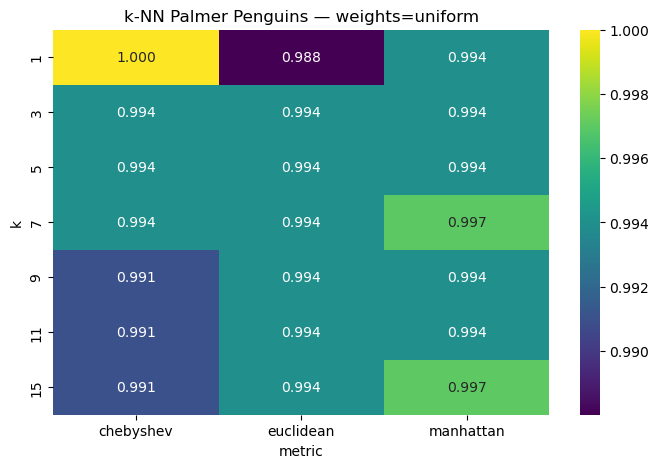

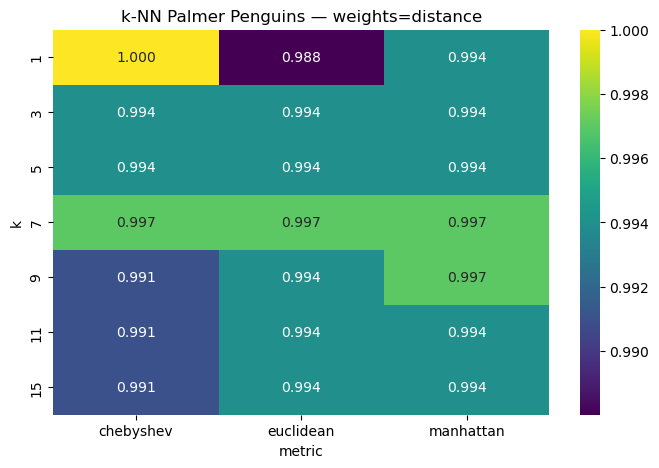

In [59]:
for weights in weights_list:
    heatmap_data = knn_results[knn_results["weights"] == weights].pivot(
        index="k",
        columns="metric",
        values="cv_accuracy_mean"
    )
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"k-NN Palmer Penguins - weights={weights}")
    plt.ylabel("k")
    plt.xlabel("metric")
    plt.show()

Dla zbioru Palmer Penguins klasyfikator k-NN osiąga bardzo wysoką skuteczność, w wielu konfiguracjach bliską 1.0. Najlepsze wyniki pojawiają się m.in. dla małych wartości `k`, ale takie modele mogą być bardziej podatne na wariancję. Wyniki dla różnych metryk są bardzo zbliżone, co oznacza, że po skalowaniu i kodowaniu cech gatunki pingwinów są dobrze separowalne.

In [60]:
nyt_url = "http://home.agh.edu.pl/~czech/vis-datasets/misc/nyt-frame.csv"

nyt_df = pd.read_csv(nyt_url)
display(nyt_df.head())
print(nyt_df.shape)
print(nyt_df.dtypes.head(10))

,Unnamed: 0,class.labels,X.,X.d,X.nd,X.s,X.th,X.this,a,abandoned,...,yorkers,yorks,you,young,younger,your,youre,youth,youthful,yu
0,1,art,0.008707,0.0,0.0,0.000000,0.009251,0.0,0.007564,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,art,0.005848,0.0,0.0,0.000000,0.000000,0.0,0.001418,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,art,0.016036,0.0,0.0,0.011403,0.000000,0.0,0.010063,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,art,0.026415,0.0,0.0,0.000000,0.000000,0.0,0.008677,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,art,0.007285,0.0,0.0,0.011008,0.000000,0.0,0.008390,0.0,...,0.0,0.0,0.048151,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(102, 4433)
Unnamed: 0        int64
class.labels     object
X.              float64
X.d             float64
X.nd            float64
X.s             float64
X.th            float64
X.this          float64
a               float64
abandoned       float64
dtype: object


In [62]:
#target i cechy
target_col_nyt = "class.labels"

X_nyt = nyt_df.drop(columns=[target_col_nyt])

#usuniecie kolumny indeksowej, jeśli istnieje
if "Unnamed: 0" in X_nyt.columns:
    X_nyt = X_nyt.drop(columns=["Unnamed: 0"])

y_nyt_raw = nyt_df[target_col_nyt]

#kodowanie etykiet
label_encoder_nyt = LabelEncoder()
y_nyt = label_encoder_nyt.fit_transform(y_nyt_raw)

print("Klasy:", dict(zip(label_encoder_nyt.classes_, label_encoder_nyt.transform(label_encoder_nyt.classes_))))
print("X NYT:", X_nyt.shape)

Klasy: {'art': np.int64(0), 'music': np.int64(1)}
X NYT: (102, 4431)


In [63]:
nyt_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10, random_state=RNG))
])

X_nyt_pca = nyt_pipeline.fit_transform(X_nyt)

print("Po PCA:", X_nyt_pca.shape)
print("Wyjaśniona wariancja:", nyt_pipeline.named_steps["pca"].explained_variance_ratio_.sum())

Po PCA: (102, 10)
Wyjaśniona wariancja: 0.1637029236811174


In [64]:
nyt_rows = []

for k in k_values:
    for metric in metrics:
        for weights in weights_list:
            knn = KNeighborsClassifier(
                n_neighbors=k,
                metric=metric,
                weights=weights
            )
            
            scores = cross_val_score(
                knn,
                X_nyt_pca,
                y_nyt,
                cv=cv5,
                scoring="accuracy"
            )
            
            nyt_rows.append({
                "k": k,
                "metric": metric,
                "weights": weights,
                "cv_accuracy_mean": scores.mean(),
                "cv_accuracy_std": scores.std()
            })

nyt_results = pd.DataFrame(nyt_rows)
display(nyt_results.sort_values("cv_accuracy_mean", ascending=False))

,k,metric,weights,cv_accuracy_mean,cv_accuracy_std
18,7,euclidean,uniform,0.822857,0.093224
13,5,euclidean,distance,0.813333,0.048036
12,5,euclidean,uniform,0.813333,0.048036
19,7,euclidean,distance,0.813333,0.096475
6,3,euclidean,uniform,0.804286,0.028107
7,3,euclidean,distance,0.804286,0.028107
36,15,euclidean,uniform,0.803810,0.081547
37,15,euclidean,distance,0.803810,0.081547
15,5,manhattan,distance,0.794286,0.057234
20,7,manhattan,uniform,0.793810,0.058352


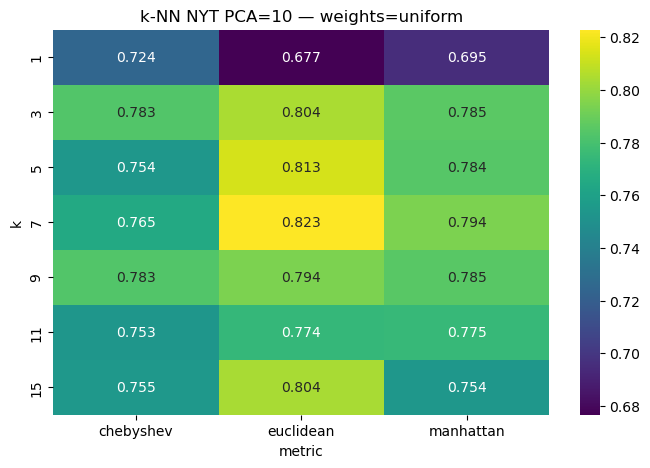

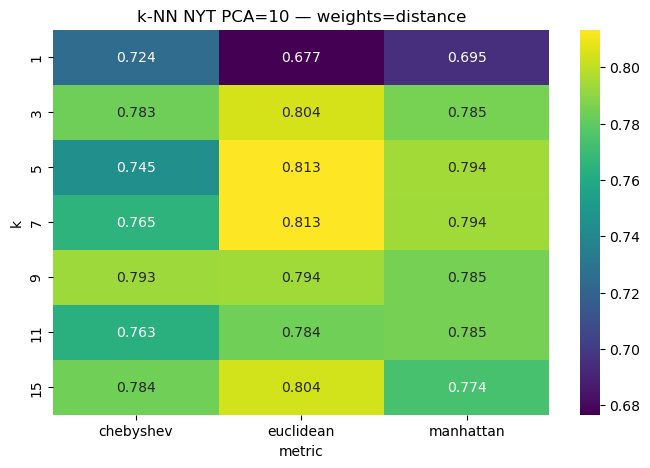

In [65]:
for weights in weights_list:
    heatmap_data = nyt_results[nyt_results["weights"] == weights].pivot(
        index="k",
        columns="metric",
        values="cv_accuracy_mean"
    )
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"k-NN NYT PCA=10 - weights={weights}")
    plt.ylabel("k")
    plt.xlabel("metric")
    plt.show()

Dla zbioru NYT po redukcji PCA do 10 wymiarów najlepsze wyniki uzyskuje głównie metryka `euclidean`. Najwyższa dokładność CV wynosi około `0.823` dla `weights=uniform`, `k=7`, `metric=euclidean`. Bardzo zbliżone wyniki występują też dla `weights=distance`, szczególnie przy `k=5` lub `k=7` i metryce `euclidean`.

W porównaniu ze zbiorem Palmer Penguins wyniki są niższe i bardziej zależne od metryki. Wynika to z tego, że NYT-frame jest zbiorem tekstowym o bardzo dużej liczbie cech, a po redukcji PCA zachowana jest tylko część informacji. Wybór metryki ma więc większe znaczenie. Metryka `euclidean` najlepiej pasuje do przestrzeni po PCA, natomiast `chebyshev` i `manhattan` zwykle dają nieco słabsze wyniki.

In [66]:
from sklearn.neighbors import KDTree
from scipy.spatial import cKDTree
import time

np.random.seed(RNG)

X_random = np.random.random((10_000, 10))
query_points = np.random.random((1_000, 10))

In [67]:
def brute_force_nn(X, queries):
    distances = np.sqrt(((queries[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))
    return np.argmin(distances, axis=1)

In [68]:
times = {}

start = time.perf_counter()
brute_idx = brute_force_nn(X_random, query_points)
times["brute_force_numpy"] = time.perf_counter() - start

start = time.perf_counter()
sk_tree = KDTree(X_random)
_, sk_idx = sk_tree.query(query_points, k=1)
times["sklearn_KDTree"] = time.perf_counter() - start

start = time.perf_counter()
scipy_tree = cKDTree(X_random)
_, scipy_idx = scipy_tree.query(query_points, k=1)
times["scipy_cKDTree"] = time.perf_counter() - start

times_df = pd.DataFrame({
    "method": list(times.keys()),
    "time_seconds": list(times.values())
}).sort_values("time_seconds")

display(times_df)

,method,time_seconds
2,scipy_cKDTree,0.089077
1,sklearn_KDTree,0.162236
0,brute_force_numpy,2.199870


KD-tree i cKDTree są szybsze od brute-force, ponieważ nie muszą porównywać zapytania ze wszystkimi punktami. W wyższych wymiarach przewaga struktur drzewiastych może jednak maleć, ponieważ działa tzw. curse of dimensionality -> oznacza, że wraz ze wzrostem liczby wymiarów punkty stają się coraz bardziej 'oddalone' i podobnie odległe od siebie.

In [69]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 1, 20),
        "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"]),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"])
    }
    
    knn = KNeighborsClassifier(**params)
    
    scores = cross_val_score(
        knn,
        X_penguins_prep,
        y_penguins,
        cv=5,
        scoring="accuracy"
    )
    
    return scores.mean()


study_knn = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RNG)
)

study_knn.optimize(objective_knn, n_trials=30)

print("Najlepszy wynik accuracy:", study_knn.best_value)
print("Najlepsze parametry:")
print(study_knn.best_params)

Najlepszy wynik accuracy: 0.9970149253731343
Najlepsze parametry:
{'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'uniform'}


In [70]:
def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 1, 20),
        "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"]),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"])
    }
    
    knn = KNeighborsClassifier(**params)
    
    scores = cross_val_score(
        knn,
        X_penguins_prep,
        y_penguins,
        cv=5,
        scoring="accuracy"
    )
    
    return scores.mean()


study_knn = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RNG)
)

study_knn.optimize(objective_knn, n_trials=30)

print("Najlepszy wynik accuracy:", study_knn.best_value)
print("Najlepsze parametry:")
print(study_knn.best_params)

Najlepszy wynik accuracy: 0.9970149253731343
Najlepsze parametry:
{'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'uniform'}


Optuna wskazała jako najlepszą konfigurację k-NN: `n_neighbors = 8`, `metric = euclidean`, `weights = uniform`. Średnia dokładność CV wyniosła około `0.997`, czyli model bardzo dobrze klasyfikuje gatunki pingwinów. Wynik jest zgodny z wcześniejszą analizą grid search, gdzie wiele konfiguracji osiągało bardzo wysoką skuteczność.

## Podsumowanie odpowiedzi do raportu

1. Najskuteczniejszą strategią regularyzacji drzewa okazał się post-pruning CCP, ponieważ uzyskał najlepszy wynik testowy i mały overfit gap.

2. Rankingi built-in importance, permutation importance i SHAP są częściowo spójne - najważniejsze są głównie `relationship`, `capital-gain`, `education-num` i `age`. Różnice wynikają z tego, że każda metoda mierzy ważność cech inaczej.

3. Random Forest poprawia wynik względem pojedynczego drzewa, ponieważ zmniejsza wariancję przez uśrednianie wielu drzew. HistGradientBoosting daje jeszcze lepszy wynik, ale kosztem mniejszej interpretowalności i większej złożoności.

4. Dla `max_features` najlepsze są wartości pośrednie, np. `2`, `sqrt` lub `log2`. Zbyt małe wartości dają słabe podziały, a zbyt duże zwiększają korelację między drzewami.

5. Zbiór Adult Census niesie ryzyka fairness, ponieważ model przewiduje klasę pozytywną z różną częstością dla grup `sex` i `race`. Widać różnice w demographic parity oraz w metrykach equalized odds.